# 1D-CNNタスク

241024  
- モデルの作成とdataloaderは終了
- データを秒数ごと二圧縮する処理を作ろう。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

## データ前処理

In [2]:
bidet_df = pd.read_csv('/Users/tomokitakata/Desktop/Tarantula/Water Disaggregation/WEUSEDTO-Data/Dataset/feed_Bidet.MYD.csv', sep=',')
bidet_df.columns = ['Time', 'bidet_flow']

# dishwasher_df = pd.read_csv('/Users/tomokitakata/Desktop/Tarantula/Water Disaggregation/WEUSEDTO-Data/Dataset/feed_Dishwasher30.MYD.csv', sep='\\s+')
# dishwasher_df.columns = ['Time', 'dishwasher_flow', 'dishwasher_endtime']

kitchenfaucet_df = pd.read_csv('/Users/tomokitakata/Desktop/Tarantula/Water Disaggregation/WEUSEDTO-Data/Dataset/feed_Kitchenfaucet.MYD.csv', sep=',')
kitchenfaucet_df.columns = ['Time', 'kitchenfaucet_flow']

shower_df = pd.read_csv('/Users/tomokitakata/Desktop/Tarantula/Water Disaggregation/WEUSEDTO-Data/Dataset/feed_Shower.MYD.csv', sep='\\s+',header=None)
shower_df.columns = ['Time', 'shower_flow']
# display(shower_df.head())

washbasin_df = pd.read_csv('/Users/tomokitakata/Desktop/Tarantula/Water Disaggregation/WEUSEDTO-Data/Dataset/feed_Washbasin.MYD.csv', sep='\\s+', header=None)
washbasin_df.columns = ['Time', 'washbasin_flow']
# display(washbasin_df.head())

# washingmachine_df = pd.read_csv('/Users/tomokitakata/Desktop/Tarantula/Water Disaggregation/WEUSEDTO-Data/Dataset/feed_Washingmachine.MYD.csv', sep='\\s+', header=None)
# washingmachine_df.columns = ['Time', 'washingmachine_low']
# # display(washingmachine_df.head())

# wholehouse_df = pd.read_csv('/Users/tomokitakata/Desktop/Tarantula/Water Disaggregation/WEUSEDTO-Data/Dataset/feed_WholeHouse.MYD.csv', sep='\\s+', header=None)
# wholehouse_df.columns = ['Time', 'wholehouse_flow']
# # display(wholehouse_df.head())

# toilet_df = pd.read_csv('/Users/tomokitakata/Desktop/Tarantula/Water Disaggregation/WEUSEDTO-Data/Dataset/feed.Toilet.csv', sep='\\s+')
# toilet_df.columns = ['Time', 'toilet_flow', 'toilet_endtime']
# # display(toilet_df.head())

In [3]:
# Time列を基準にデータフレームをマージ
merged_df = bidet_df.merge(kitchenfaucet_df, on='Time', how='outer') \
                    .merge(shower_df, on='Time', how='outer') \
                    .merge(washbasin_df, on='Time', how='outer') \

# マージしたデータフレームを表示
display(merged_df.head(10))

merged_df = merged_df.iloc[1:, :] #最初の秒数0のデータはエラー？なので削除
starttime = merged_df.iloc[0,0] # 開始時間を取得
merged_df['Time'] -= starttime # 開始時間を引いて経過時間とする。

,Time,bidet_flow,kitchenfaucet_flow,shower_flow,washbasin_flow
0,0,NaN,NaN,NaN,0.0
1,1550048169,NaN,NaN,NaN,0.0
2,1550048311,NaN,NaN,NaN,123.0
3,1550048312,NaN,NaN,NaN,54.0
4,1550056694,NaN,NaN,90.0,NaN
5,1550056695,NaN,NaN,139.0,NaN
6,1550056697,NaN,NaN,65.0,NaN
7,1550056698,NaN,NaN,2.0,NaN
8,1550056700,NaN,NaN,2.0,NaN
9,1550057001,NaN,NaN,0.0,NaN


In [4]:
merged_df.fillna(0, inplace=True) # 欠損値処理
merged_df.sort_values(by='Time', ascending=True) #Timeの列を基準にsort
merged_df['gross'] = merged_df['bidet_flow'] + merged_df['kitchenfaucet_flow'] + merged_df['shower_flow'] + merged_df['washbasin_flow']

merged_df_2019 = merged_df[merged_df.Time <= 30000000].reset_index(drop=True) # 2019年データ
merged_df_2020 = merged_df[merged_df.Time >= 30000000].reset_index(drop=True) # 2020年データ


# Timeを計測開始時刻からの経過時間に変更
starttime_2019 = merged_df_2019.copy().iloc[0,0]
starttime_2020 = merged_df_2020.copy().iloc[0,0]

merged_df_2019.Time -= starttime_2019
merged_df_2020.Time -= starttime_2020

In [5]:
# 時系列をすべて作成。
max_2019 = max(merged_df_2019.Time)
sequence_2019 = np.arange(1, max_2019)
df_sequence_2019 = pd.DataFrame(sequence_2019, columns=['Time'])
merged_df_2019 = pd.merge(df_sequence_2019, merged_df_2019, on='Time', how='left').fillna(0)

max_2020 = max(merged_df_2020.Time)
sequence_2020 = np.arange(1, max_2020)
df_sequence_2020 = pd.DataFrame(sequence_2020, columns=['Time'])
merged_df_2020 = pd.merge(df_sequence_2020, merged_df_2020, on='Time', how='left').fillna(0)

In [6]:
display(merged_df_2020)

,Time,bidet_flow,kitchenfaucet_flow,shower_flow,washbasin_flow,gross
0,1,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
10746654,10746655,0.0,0.0,0.0,0.0,0.0
10746655,10746656,0.0,0.0,0.0,0.0,0.0
10746656,10746657,0.0,0.0,0.0,0.0,0.0
10746657,10746658,0.0,0.0,0.0,0.0,0.0


In [7]:
# 時系列データを指定された秒数ごとに合計する関数
def complessed_data(df, interval):
    """
    時系列データを指定された秒数ごとに合計する関数

    Parameters:
    df (pd.DataFrame): 時系列データを含むデータフレーム
    time_column (str): 時間を示すカラム名（例: 'Time_group'）
    data_columns (list): 合計したいデータのカラム名（例: ['flow1', 'flow2']）
    interval (int): データを合計する秒数（例: 6, 10, 60）

    Returns:
    pd.DataFrame: 指定した秒数ごとにデータが合計されたデータフレーム
    """
    # Time列をintervalごとにグループ化してデータを合計
    df['Time_group'] = (df['Time'] // interval) * interval
    resampled_df = df.groupby('Time_group')[['bidet_flow', 'kitchenfaucet_flow', 'shower_flow','washbasin_flow', 'gross']].sum().reset_index()
    
    return resampled_df



# 標準化する関数（Time_group列以外）
def standardize_columns(df):
    # Time_group列以外を選択
    columns_to_standardize = df.columns.difference(['Time_group'])
    
    # 平均と標準偏差を計算
    means = df[columns_to_standardize].mean()
    stds = df[columns_to_standardize].std()
    
    # 標準化を適用
    df[columns_to_standardize] = (df[columns_to_standardize] - means) / stds
    
    # 平均と標準偏差を返す
    return df, means, stds

# np.arrayを元に戻す関数
def inverse_standardize_array(array, means, stds):
    """
    array: 標準化された np.array データ
    means: 元データの平均 (形状: (4,))
    stds: 元データの標準偏差 (形状: (4,))
    """
    # 余分な列を含まないように4つの設備に対応するmeanとstdを選択
    means = means.drop('gross').values.reshape(1, -1)  # (1, 4)
    stds = stds.drop('gross').values.reshape(1, -1)    # (1, 4)
    
    # 元のスケールに戻す
    original_array = (array * stds) + means
    
    return original_array


# ランダムな始点を決めて等間隔でサンプリングする関数
# def random_resample(df, interval, num_samples=600, seed=None):
#     '''
#     df: サンプリング対象のデータフレーム
#     interval: 何秒ごとにするか(本件では 6 or 10 or 60)
#     num_samples: 何個サンプリングするか(本件では基本的に600)
#     seed: ランダムサンプリングの再現性を保つためのseed
#     '''
#     # シードを固定してランダムな始点を決定
#     if seed is not None:
#         np.random.seed(seed)
    
#     # Time列の範囲内でランダムな始点を決める
#     start_time = np.random.uniform(df['Time_group'].min(), df['Time_group'].max() - (interval * (num_samples - 1)))
    
#     # print(f"ランダムな始点: {start_time}")
    
#     # ランダムな始点から interval ごとに num_samples 個の時間点を生成
#     new_time = np.arange(start_time, start_time + interval * num_samples, interval)
    
#     # Time列と補間対象のフローデータを取得
#     time_values = df['Time_group'].values
#     flows = df[['bidet_flow', 'kitchenfaucet_flow', 'shower_flow', 'washbasin_flow', 'gross']].values
    
#     # 各列に対して線形補間を実行
#     resampled_flows = griddata(time_values, flows, new_time, method='linear')
    
#     # 新しいデータフレームを作成
#     resampled_df = pd.DataFrame(resampled_flows, columns=['bidet_flow', 'kitchenfaucet_flow', 'shower_flow', 'washbasin_flow', 'gross'])
#     resampled_df['Time_group'] = new_time

#     resampled_df = normalize_columns(resampled_df)
    
#     return resampled_df


# データを訓練、検証、テストに分割する関数
def split_data(df, train_size=0.6, test_size=0.25, valid_size=0.15, seed=None):
    '''
    df: データ分割対象のデータフレーム
    train_size: 何秒ごとにするか(本件では 6 or 10 or 60)
    test_size: 何個サンプリングするか(本件では基本的に600)
    valid_size: ランダムサンプリングの再現性を保つためのseed
    '''
    # データのサイズを確認
    if train_size + valid_size + test_size != 1.0:
        raise ValueError("train_size, valid_size, and test_size must sum to 1.0")
    
    # まず、訓練用データとテスト+検証用データに分割
    train_data, temp_data = train_test_split(df, train_size=train_size, random_state=seed)
    
    # 残りのテスト+検証用データをさらにテスト用と検証用に分割
    valid_ratio = valid_size / (valid_size + test_size)  # 残りのデータに対する検証データの割合
    valid_data, test_data = train_test_split(temp_data, train_size=valid_ratio, random_state=seed)

    train_data.sort_values(by='Time_group', inplace=True)
    test_data.sort_values(by='Time_group', inplace=True)
    valid_data.sort_values(by='Time_group', inplace=True)
    
    return train_data, test_data, valid_data


In [8]:
# データの秒数ごとの合計、正規化、train-test分割を実施。
# 2019年データを使用してみる。

data = merged_df_2020.copy()
data = complessed_data(data, 6)
data, means, stds = standardize_columns(data)
display(means)
display(data.head())
train, test, valid = split_data(data, seed=0)

bidet_flow            0.222561
gross                 3.301292
kitchenfaucet_flow    0.919419
shower_flow           1.574999
washbasin_flow        0.584313
dtype: float64

,Time_group,bidet_flow,kitchenfaucet_flow,shower_flow,washbasin_flow,gross
0,0,-0.028784,-0.051641,-0.052897,-0.046675,-0.086259
1,6,-0.028784,-0.051641,-0.052897,-0.046675,-0.086259
2,12,-0.028784,-0.051641,-0.052897,-0.046675,-0.086259
3,18,-0.028784,-0.051641,-0.052897,-0.046675,-0.086259
4,24,-0.028784,-0.051641,-0.052897,-0.046675,-0.086259


- train_test_splitの方法について
    - ランダムに分けるか、時系列性を保って分けるか

- 要相談

## 1D-CNNの実装

- これで問題なさそう？
    - 損失関数はマルチMSEとかありそう？？

- paddingについて調べる
    - padding = 2, padding = 1の妥当性。
    - 次の層の次元を揃えるために使用している。

- パディング
    - パディングの2はフィルターがデータの端で情報を失わないように、左右に2つの0を追加することを意味する。これにより入力の時系列データの長さを保持しつつ、端でも畳み込みを実行することが可能。
- バッチ
    - 機械学習や深層学習でモデルが1回のパラメータ更新(つまり1ステップの学習)で処理するサンプル数を指す。
    - バッチサイズが600説。

- L=600は、時系列のwindowサイズを表している。
- バッチサイズは4096。これは一度にモデルに入力されるサンプルデータの数。
- バッチサイズ（batch size）4096は、一度にモデルに入力されるサンプルの数を指します。各バッチには4096サンプルが含まれ、それぞれが600のフレーム長を持つ時系列データです。
- エポックが何回学習させるか。今回はearly stoppingありの50回。


### データローダーの作成
ここでは、データをCNNに流し込める形状に変形し、data loaderに代入を実施。

In [9]:
# 1. データの割合を設定
train_ratio, valid_ratio, test_ratio = 0.65, 0.15, 0.20

# 必要なハイパーパラメータを設定
window_size = 600
batch_count = 4096  # バッチ数4096
required_length = window_size * batch_count  # 必要なデータの長さ


# 2. 順序通りのウィンドウ抽出関数
def extract_sequential_windows(data, window_size, batch_count):
    num_windows = len(data) // window_size  # 利用可能なウィンドウ数
    windows = np.array([data[i*window_size:(i+1)*window_size] for i in range(batch_count)])
    return windows

# 3. ランダムにウィンドウを抽出して補完する関数
def extract_random_windows(data, window_size, required_windows):
    data_length = len(data)
    windows = []
    
    for _ in range(required_windows):
        # ランダムにウィンドウの開始位置を決定
        start_index = np.random.randint(0, data_length - window_size)
        window = data[start_index:start_index + window_size]
        windows.append(window)
    
    windows = np.array(windows)
    return windows

# 4. 同じウィンドウ範囲で元栓データと設備データを抽出
def extract_synced_windows(main_data, equip_data, window_size, batch_count):
    if len(main_data) >= required_length:
        # 十分なデータがある場合は順にウィンドウを抽出
        main_windows = extract_sequential_windows(main_data, window_size, batch_count)
        equip_windows = extract_sequential_windows(equip_data, window_size, batch_count)
    else:
        # データが不足している場合は順に取りつつ、ランダムに補完
        available_windows = len(main_data) // window_size
        main_windows_seq = extract_sequential_windows(main_data, window_size, available_windows)
        equip_windows_seq = extract_sequential_windows(equip_data, window_size, available_windows)
        
        # ランダムにウィンドウを抽出して必要な数まで補完
        missing_windows = batch_count - available_windows
        main_windows_rand = extract_random_windows(main_data, window_size, missing_windows)
        equip_windows_rand = extract_random_windows(equip_data, window_size, missing_windows)
        
        # 順序通りのウィンドウとランダムなウィンドウを結合
        main_windows = np.concatenate([main_windows_seq, main_windows_rand], axis=0)
        equip_windows = np.concatenate([equip_windows_seq, equip_windows_rand], axis=0)
    
    return main_windows, equip_windows


In [10]:
# 19500秒〜196100秒の範囲外のデータを選別
train_valid_data = data.query('Time_group < 19500 or Time_group > 196100')

# テストデータとして19500秒〜196100秒の範囲のデータを取得
test_data = data.query('19500 <= Time_group <= 196100')

# 訓練、検証用のデータの長さを取得
train_valid_length = len(train_valid_data)

# 訓練、検証データを分割するインデックスを計算
train_size = int(train_valid_length * train_ratio)
valid_size = int(train_valid_length * valid_ratio)

# 訓練、検証のインデックス範囲を設定
train_idx = np.arange(0, train_size)
valid_idx = np.arange(train_size, train_size + valid_size)

# 訓練、検証のデータを作成
gross_data_train = train_valid_data.gross.iloc[train_idx]  # 元栓データ
equipment_data_train = train_valid_data.drop(['gross', 'Time_group'], axis=1).iloc[train_idx]  # disaggregate後のデータ

gross_data_valid = train_valid_data.gross.iloc[valid_idx]
equipment_data_valid = train_valid_data.drop(['gross', 'Time_group'], axis=1).iloc[valid_idx]

# テストデータの作成
gross_data_test = test_data['gross']
equipment_data_test = test_data.drop(['gross', 'Time_group'], axis=1)

# 4. 同じウィンドウ範囲で元栓データと設備データを抽出する関数を再利用
main_windows_train, equip_windows_train = extract_synced_windows(gross_data_train, equipment_data_train, window_size, batch_count)
main_windows_valid, equip_windows_valid = extract_synced_windows(gross_data_valid, equipment_data_valid, window_size, batch_count)
main_windows_test, equip_windows_test = extract_synced_windows(gross_data_test, equipment_data_test, window_size, batch_count)

# 6. チャンネル次元を追加 (main_windowsは (4096, 1, 600)、equip_windowsは (4096, 4, 600) にする)
main_windows_train = main_windows_train.reshape(batch_count, 1, window_size)
equip_windows_train = equip_windows_train.transpose(0, 2, 1)  # (4096, 4, 600)

main_windows_valid = main_windows_valid.reshape(batch_count, 1, window_size)
equip_windows_valid = equip_windows_valid.transpose(0, 2, 1)  # (4096, 4, 600)

main_windows_test = main_windows_test.reshape(batch_count, 1, window_size)
equip_windows_test = equip_windows_test.transpose(0, 2, 1)  # (4096, 4, 600)

# NumPy配列をPyTorchテンソルに変換 (訓練データ)
inputs_tensor_train = torch.tensor(main_windows_train, dtype=torch.float32)
targets_tensor_train = torch.tensor(equip_windows_train, dtype=torch.float32)

# 検証データ
inputs_tensor_valid = torch.tensor(main_windows_valid, dtype=torch.float32)
targets_tensor_valid = torch.tensor(equip_windows_valid, dtype=torch.float32)

# テストデータ
inputs_tensor_test = torch.tensor(main_windows_test, dtype=torch.float32)
targets_tensor_test = torch.tensor(equip_windows_test, dtype=torch.float32)

# TensorDatasetとDataLoaderを作成
train_dataset = TensorDataset(inputs_tensor_train, targets_tensor_train)
valid_dataset = TensorDataset(inputs_tensor_valid, targets_tensor_valid)
test_dataset = TensorDataset(inputs_tensor_test, targets_tensor_test)

# DataLoaderを作成
train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=4096, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4096, shuffle=False)

# デバイス設定（GPUが使用可能か確認）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 結果の確認
print(f"Train Data Shape: {inputs_tensor_train.shape}, {targets_tensor_train.shape}")
print(f"Valid Data Shape: {inputs_tensor_valid.shape}, {targets_tensor_valid.shape}")
print(f"Test Data Shape: {inputs_tensor_test.shape}, {targets_tensor_test.shape}")

Train Data Shape: torch.Size([4096, 1, 600]), torch.Size([4096, 4, 600])
Valid Data Shape: torch.Size([4096, 1, 600]), torch.Size([4096, 4, 600])
Test Data Shape: torch.Size([4096, 1, 600]), torch.Size([4096, 4, 600])


In [11]:
# DataLoaderの中身を表示する関数
def inspect_dataloader(dataloader, num_batches=1):
    """
    DataLoaderの中身を確認するための関数
    
    Parameters:
    dataloader: PyTorch DataLoaderオブジェクト
    num_batches: 確認したいバッチの数（デフォルト: 1）
    """
    for batch_idx, (inputs, targets) in enumerate(dataloader):
        print(f"Batch {batch_idx + 1}")
        print("Inputs (shape):", inputs.shape)
        print("Targets (shape):", targets.shape)
        print("Inputs (first 5 examples):", inputs[:5])  # 最初の5つの入力を表示
        print("Targets (first 5 examples):", targets[:5])  # 最初の5つのターゲットを表示
        
        if batch_idx + 1 == num_batches:
            break  # 指定したバッチ数だけ表示して終了

# train_loader, valid_loader, test_loader など任意のDataLoaderで確認
inspect_dataloader(train_loader, num_batches=2)  # 最初の2バッチを確認

Batch 1
Inputs (shape): torch.Size([4096, 1, 600])
Targets (shape): torch.Size([4096, 4, 600])
Inputs (first 5 examples): tensor([[[-0.0863, -0.0863, -0.0863,  ..., -0.0863, -0.0863, -0.0863]],

        [[-0.0863, -0.0863, -0.0863,  ..., -0.0863, -0.0863, -0.0863]],

        [[-0.0863, -0.0863, -0.0863,  ..., 24.9192, 20.7647, 24.3182]],

        [[-0.0863, -0.0863, -0.0863,  ..., -0.0863, -0.0863, -0.0863]],

        [[-0.0863, -0.0863, -0.0863,  ..., -0.0863, -0.0863, -0.0863]]])
Targets (first 5 examples): tensor([[[-0.0288, -0.0288, -0.0288,  ..., -0.0288, -0.0288, -0.0288],
         [-0.0516, -0.0516, -0.0516,  ..., -0.0516, -0.0516, -0.0516],
         [-0.0529, -0.0529, -0.0529,  ..., -0.0529, -0.0529, -0.0529],
         [-0.0467, -0.0467, -0.0467,  ..., -0.0467, -0.0467, -0.0467]],

        [[-0.0288, -0.0288, -0.0288,  ..., -0.0288, -0.0288, -0.0288],
         [-0.0516, -0.0516, -0.0516,  ..., -0.0516, -0.0516, -0.0516],
         [-0.0529, -0.0529, -0.0529,  ..., -0.0529, -0.05

### 評価指標
論文中で記載の評価指標を作成

In [12]:
# EAC (Estimated Accuracy)
def eac(y_true, y_pred):
    numerator = np.sum(np.abs(y_pred - y_true))
    denominator = 2 * np.sum(y_true)
    return 1 - numerator / denominator

# NDE (Normalized Disaggregation Error)
def nde(y_true, y_pred):
    numerator = np.sum((y_pred - y_true) ** 2)
    denominator = np.sum(y_true ** 2)
    return np.sqrt(numerator / denominator)

# MAE (Mean Absolute Error)
def mae(y_true, y_pred):
    return np.mean(np.abs(y_pred - y_true))

# 評価指標を計算する関数
def calculate_metrics(y_true, y_pred):
    eac_value = eac(y_true, y_pred)
    nde_value = nde(y_true, y_pred)
    mae_value = mae(y_true, y_pred)
    
    return eac_value, nde_value, mae_value

### 1D-CNN
論文中で記載の内容でモデルを作成

In [13]:
# 1D-CNNモデルの定義
class CNN1DModel(nn.Module):
    def __init__(self, input_channels, num_outputs):
        super(CNN1DModel, self).__init__()
        
        # 畳み込み層の定義
        self.conv1 = nn.Conv1d(in_channels=input_channels, out_channels=16, kernel_size=5, stride=2, padding=2)
        self.bn1 = nn.BatchNorm1d(16)

        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=2, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm1d(64)
        
        self.conv4 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1)
        self.bn4 = nn.BatchNorm1d(128)
        
        # Adaptive avg pooling
        self.adaptive_avg_pool = nn.AdaptiveAvgPool1d(16)
        
        # MLP層。最終的なアウトプットは600秒間の4つの設備データ
        # FC層を3層に分ける
        self.fc1 = nn.Linear(128 * 16, 1024)  # 2048次元 → 1024次元
        self.fc2 = nn.Linear(1024, 512)      # 1024次元 → 512次元
        self.fc3 = nn.Linear(512, num_outputs)  # 512次元 → 2400次元（4 * 600）

        self.relu = nn.ReLU()
        
    def forward(self, x):
        # 畳み込み層とバッチ正規化、ReLU
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))
        
        # Adaptive avg pooling
        x = self.adaptive_avg_pool(x)
        x = x.view(x.size(0), -1)  # フラット化 (batch_size, 128 * 16)
        
        # 全結合層
        x = self.relu(self.fc1(x))  # (batch_size, 1024)
        x = self.relu(self.fc2(x))  # (batch_size, 512)
        x = self.fc3(x)             # (batch_size, 2400)
        
        # 出力を (batch_size, 4, 600) にリシェイプ
        x = x.view(x.size(0), 4, 600)
        
        return x

# モデルのトレーニング
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=50, patience=5):
    best_val_loss = float('inf')  # 検証データに基づいたベスト損失
    patience_counter = 0
    early_stop = False
    
    for epoch in range(num_epochs):
        if early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        # ---- Training ----
        model.train()
        running_loss = 0.0
        all_true = []
        all_pred = []
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            
            # ロスを計算
            loss = criterion(outputs, targets)
            
            # バックプロパゲーションと最適化
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            # 出力とターゲットを保存（評価指標の計算のため）
            all_true.append(targets.detach().cpu().numpy())  # GPUからCPUへ移動
            all_pred.append(outputs.detach().cpu().numpy())  # GPUからCPUへ移動
        
        # すべてのバッチの予測と正解を結合
        y_true = np.concatenate(all_true, axis=0)
        y_pred = np.concatenate(all_pred, axis=0)
        
        # 評価指標を計算
        eac_value, nde_value, mae_value = calculate_metrics(y_true, y_pred)
        
        # 各エポックの結果を表示
        epoch_loss = running_loss / len(train_loader)
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}')
        print(f"EAC: {eac_value:.4f}, NDE: {nde_value:.4f}, MAE: {mae_value:.4f}")
        
        # ---- Validation ----
        model.eval()  # 検証モード
        val_loss = 0.0
        all_val_true = []
        all_val_pred = []

        with torch.no_grad():  # 検証時は勾配計算を行わない
            for inputs, targets in valid_loader:
                inputs, targets = inputs.to(device), targets.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()

                # 出力とターゲットを保存
                all_val_true.append(targets.detach().cpu().numpy())
                all_val_pred.append(outputs.detach().cpu().numpy())

        # 検証データの評価指標
        y_val_true = np.concatenate(all_val_true, axis=0)
        y_val_pred = np.concatenate(all_val_pred, axis=0)
        
        # 検証データに対する損失
        val_loss /= len(valid_loader)
        print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss:.4f}')

        # ---- 評価指標を追加して計算 ----
        # 評価指標を計算 (EAC, NDE, MAEなど)
        eac_value, nde_value, mae_value = calculate_metrics(y_val_true, y_val_pred)

        # 評価指標を表示
        print(f"EAC (Validation): {eac_value:.4f}, NDE (Validation): {nde_value:.4f}, MAE (Validation): {mae_value:.4f}")

        # Early Stopping のチェック
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0  # 改善があればカウンターをリセット
        else:
            patience_counter += 1  # 改善がなければカウンターを増加
            print(f"No improvement in validation loss for {patience_counter} epoch(s).")
        
        if patience_counter >= patience:
            print(f"Early stopping triggered after {patience_counter} epochs with no improvement.")
            early_stop = True  # patience が設定値に達したらトレーニングを停止

### トレーニングの実行

In [14]:

# モデルのインスタンス化とデバイスへの転送
input_channels = 1
num_outputs = 4 * 600  # 出力は4設備の時系列であるため、4 * 600
model = CNN1DModel(input_channels, num_outputs).to(device)

# 損失関数と最適化手法の定義
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# トレーニング実行例
train_model(model, train_loader, valid_loader, criterion, optimizer)

Epoch [1/50], Train Loss: 1.1711
EAC: -7.3591, NDE: 1.0014, MAE: 0.1063
Epoch [1/50], Validation Loss: 1.0987
EAC (Validation): -3.9767, NDE (Validation): 1.0003, MAE (Validation): 0.1016
Epoch [2/50], Train Loss: 1.1672
EAC: -6.9641, NDE: 0.9997, MAE: 0.1013
Epoch [2/50], Validation Loss: 1.0986
EAC (Validation): -4.0075, NDE (Validation): 1.0002, MAE (Validation): 0.1022
Epoch [3/50], Train Loss: 1.1647
EAC: -7.3446, NDE: 0.9986, MAE: 0.1061
Epoch [3/50], Validation Loss: 1.0984
EAC (Validation): -4.0750, NDE (Validation): 1.0001, MAE (Validation): 0.1036
Epoch [4/50], Train Loss: 1.1611
EAC: -8.1856, NDE: 0.9971, MAE: 0.1168
Epoch [4/50], Validation Loss: 1.0982
EAC (Validation): -4.1298, NDE (Validation): 1.0000, MAE (Validation): 0.1047
Epoch [5/50], Train Loss: 1.1567
EAC: -8.6620, NDE: 0.9952, MAE: 0.1229
Epoch [5/50], Validation Loss: 1.0981
EAC (Validation): -4.1152, NDE (Validation): 1.0000, MAE (Validation): 0.1044
Epoch [6/50], Train Loss: 1.1515
EAC: -8.5282, NDE: 0.9930, 

- 全体として損失出せているけど、facilityごとに出せていない。
- EACがマイナスになるのはなんで？

### 学習モデルによる推論
ここでtestデータによる最終的な精度評価を実施。


--- 設備 1 の評価 ---
EAC: -0.0777, NDE: 1.0013, MAE: 0.8212

--- 設備 2 の評価 ---
EAC: 0.2613, NDE: 1.0004, MAE: 1.8905

--- 設備 3 の評価 ---
EAC: 0.2741, NDE: 1.0003, MAE: 3.1625

--- 設備 4 の評価 ---
EAC: 0.2051, NDE: 1.0006, MAE: 1.3310


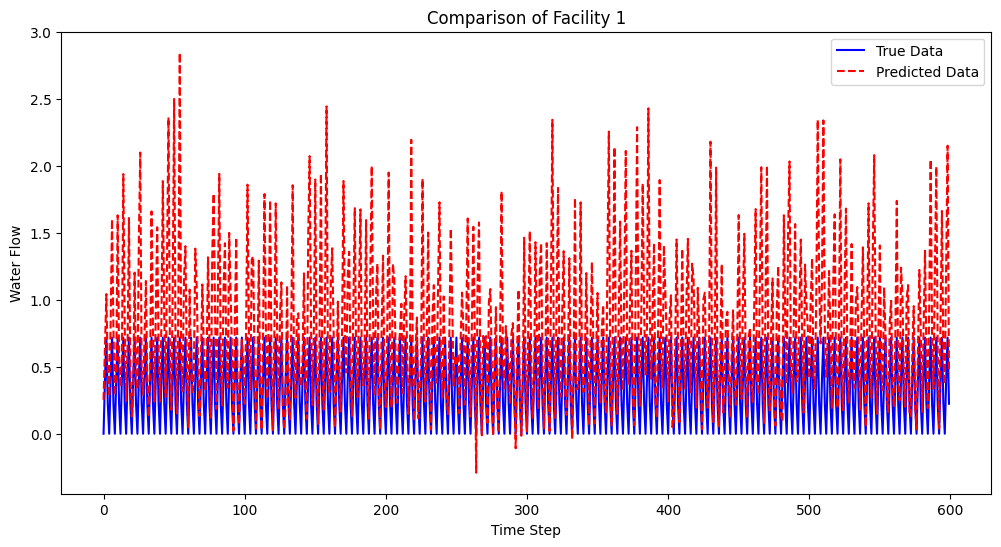

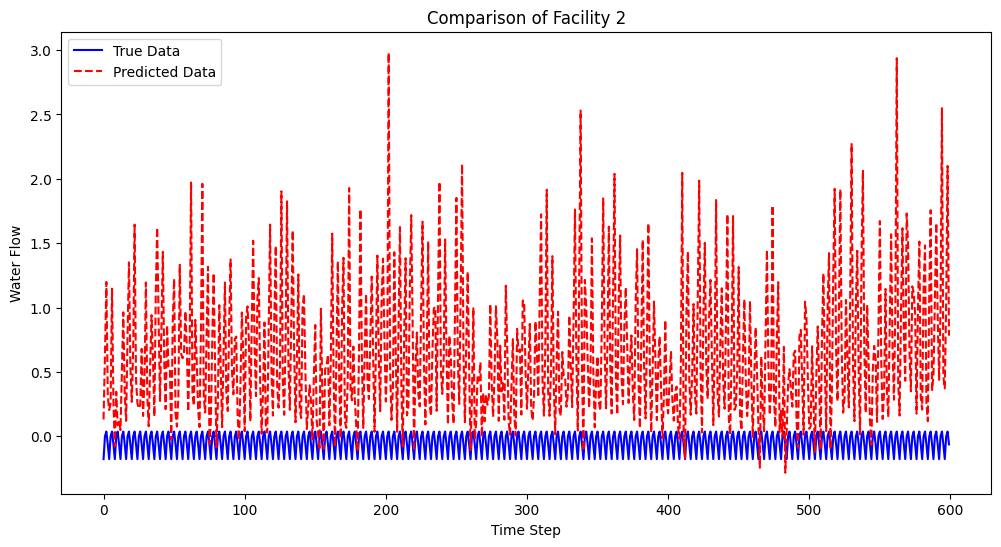

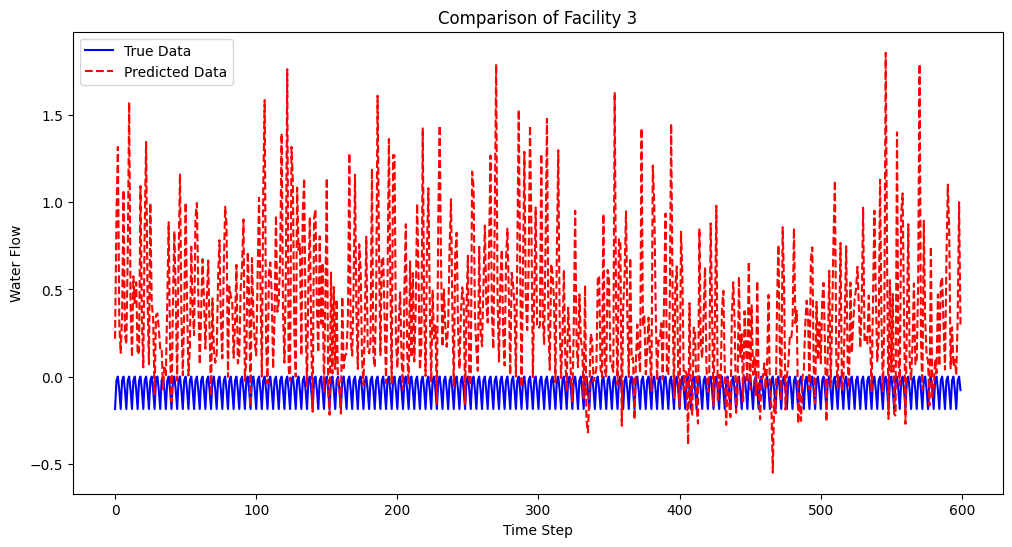

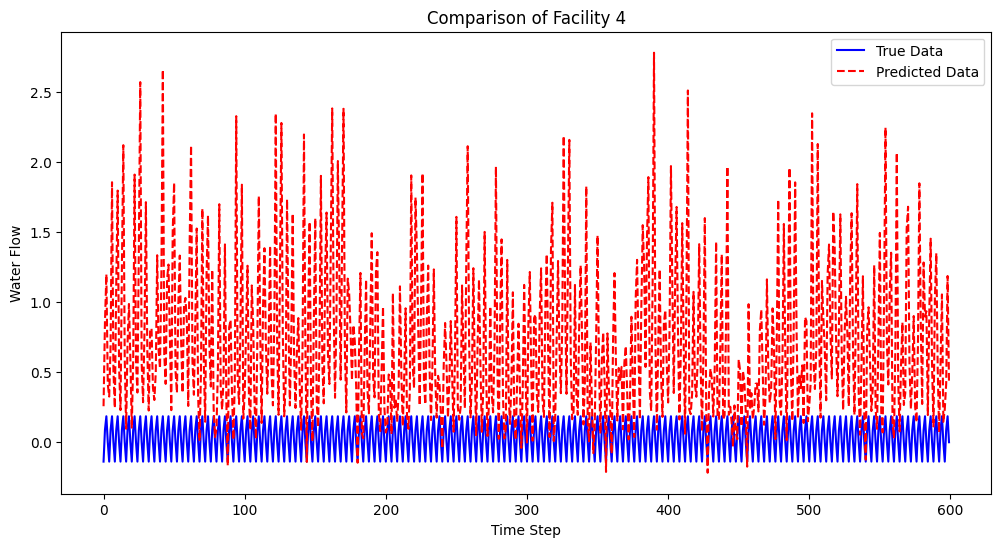

In [15]:
# 1. 予測を行う関数
def predict(model, input_data):
    model.eval()
    with torch.no_grad():
        input_data = input_data.to(device)
        predictions = model(input_data)
    return predictions.detach().cpu().numpy()

# 2. テストデータで予測を行い、設備ごとに評価指標を計算
def evaluate_model(model, test_loader, means, stds):
    all_true = []
    all_pred = []

    # テストデータでの予測
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        predictions = predict(model, inputs)
        
        # 出力を保存
        all_true.append(targets.cpu().numpy())  # 実際の値
        all_pred.append(predictions)            # 予測値

    # すべての予測結果と実際の値を結合
    y_true = np.concatenate(all_true, axis=0)
    y_pred = np.concatenate(all_pred, axis=0)

    # 標準化されたデータを元に戻す (設備データのみ)
    y_true_original = inverse_standardize_array(y_true.reshape(-1, 4), means, stds)
    y_pred_original = inverse_standardize_array(y_pred.reshape(-1, 4), means, stds)

    # 設備ごとに評価指標を計算
    for i in range(4):  # 4つの設備を対象
        print(f"\n--- 設備 {i+1} の評価 ---")
        eac_value = eac(y_true_original[:, i], y_pred_original[:, i])
        nde_value = nde(y_true_original[:, i], y_pred_original[:, i])
        mae_value = mae(y_true_original[:, i], y_pred_original[:, i])
        
        print(f"EAC: {eac_value:.4f}, NDE: {nde_value:.4f}, MAE: {mae_value:.4f}")

    return y_true_original, y_pred_original

# 3. 元データと予測データを可視化する関数
def plot_predictions(y_true, y_pred, equipment_index=0):
    """
    y_true: 実際のデータ (形状: (batch_size, 4, 600))
    y_pred: 予測データ (形状: (batch_size, 4, 600))
    equipment_index: 表示する設備のインデックス (0〜3)
    """
    plt.figure(figsize=(12, 6))
    
    # 1つのサンプルだけをプロットする（例: 1番目のサンプル）
    plt.plot(y_true[0, equipment_index, :], label='True Data', color='blue')
    plt.plot(y_pred[0, equipment_index, :], label='Predicted Data', color='red', linestyle='--')
    
    plt.title(f"Comparison of Facility {equipment_index + 1}")
    plt.xlabel("Time Step")
    plt.ylabel("Water Flow")
    plt.legend()
    plt.show()

# テストデータを使って予測と評価を実行
y_true_original, y_pred_original = evaluate_model(model, test_loader, means, stds)

# 可視化: 1番目の設備（インデックス0）について元データと予測データを表示
plot_predictions(y_true_original.reshape(-1, 4, 600), y_pred_original.reshape(-1, 4, 600), equipment_index=0)

# 例: 他の設備（インデックス1, 2, 3）についても同様に可視化
plot_predictions(y_true_original.reshape(-1, 4, 600), y_pred_original.reshape(-1, 4, 600), equipment_index=1)
plot_predictions(y_true_original.reshape(-1, 4, 600), y_pred_original.reshape(-1, 4, 600), equipment_index=2)
plot_predictions(y_true_original.reshape(-1, 4, 600), y_pred_original.reshape(-1, 4, 600), equipment_index=3)

In [16]:
y_true_original

array([[ 1.58537550e-09,  4.06948623e-01,  7.17956570e-01,
         2.23973063e-01],
       [ 1.58537550e-09,  4.06948623e-01,  7.17956570e-01,
         2.23973063e-01],
       [ 1.58537550e-09,  4.06948623e-01,  7.17956570e-01,
         2.23973063e-01],
       ...,
       [-1.38335344e-01,  8.84175816e-02,  1.85252839e-01,
         1.71084338e-08],
       [-1.38335344e-01,  8.84175816e-02,  1.85252839e-01,
         1.71084338e-08],
       [-1.38335344e-01,  8.84175816e-02,  1.85252839e-01,
         1.71084338e-08]])

### 結果の可視化